# 📺 Streaming Analytics: Predictive Strategies for Retention & Engagement

## 🧠 Strategic Executive Overview
This project focuses on converting user behaviour into **actionable insights**. To respect executive time, I am presenting the most critical outcome first: the technical feasibility of our predictive engine.

---

## 🎯 Pillar 1: Predictive Strategy
**Executive Summary:** We present a dual-stage modelling framework to demonstrate development maturity. By transitioning from a standard numerical baseline to an expanded categorical, class balanced architecture, we shift from surface-level metrics to actionable churn risk detection.

In [ ]:
# Pillar 1: Predictive Strategy (Baseline & Optimised Models)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings

# Setting up visual standards (British Executive Presentation)
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 6]
sns.set_theme(style="whitegrid", palette="muted")

# 1. Loading data and normalising column names to lowercase
df = pd.read_parquet('../data/processed/streaming_refined.parquet')
df.columns = df.columns.str.lower()

# 2. Converting 'Yes'/'No' text strings into strict 1 and 0 integers safely
binary_map = {'yes': 1, 'no': 0, 'Yes': 1, 'No': 0}

if 'discount_applied' in df.columns:
    df['discount_applied'] = df['discount_applied'].map(binary_map).fillna(0).astype(int)

if 'churn_status' in df.columns:
    df['churn_status'] = df['churn_status'].map(binary_map).fillna(0).astype(int)

# Target variable
y = df['churn_status']

# Automatically identifying what is a pure number in the dataframe to avoid KeyErrors
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
baseline_features = [col for col in numeric_cols if col not in ['churn_status', 'user_id']]

print(f"📊 Verified baseline features found in your dataset: {baseline_features}")

# ETAPA A: MODELO BASELINE (Automatic Numerical Columns)
X_baseline = df[baseline_features]

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42
)

model_base = RandomForestClassifier(n_estimators=100, random_state=42)
model_base.fit(X_train_base, y_train_base)
y_pred_base = model_base.predict(X_test_base)
acc_base = accuracy_score(y_test_base, y_pred_base)

print(f"✅ Baseline complete. Accuracy reached: {acc_base:.2%}")

# ETAPA B: MODELO OTIMIZADO (Expanded Categorical Encoding including Demographic Features)
# Including age_group and gender to catch the remaining text columns detected by the error
categorical_cols = ['payment_method', 'genre', 'content_type', 'age_group', 'gender']
existing_categorical = [col for col in categorical_cols if col in df.columns]

df_encoded = pd.get_dummies(df, columns=existing_categorical, drop_first=True, dtype=int)

# Selecting only strictly numeric columns from the encoded dataset, filtering metadata text
X_refined = df_encoded.select_dtypes(include=[np.number]).drop(
    ['churn_status', 'user_id', 'session_start_date', 'session_end_date', 'title'], 
    axis=1, 
    errors='ignore'
)

X_train_ref, X_test_ref, y_train_ref, y_test_ref = train_test_split(
    X_refined, y, test_size=0.2, random_state=42
)

model_refined = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_refined.fit(X_train_ref, y_train_ref)
y_pred_ref = model_refined.predict(X_test_ref)
acc_ref = accuracy_score(y_test_ref, y_pred_ref)

# Visualising the final Refined Confusion Matrix
plt.figure(figsize=(10, 6))
cm_ref = confusion_matrix(y_test_ref, y_pred_ref)
sns.heatmap(cm_ref, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Pillar 1: Optimised Strategic Accuracy - {acc_ref:.2%}', fontsize=16, fontweight='bold')
plt.ylabel('Actual Churn (Reality)')
plt.xlabel('Predicted Churn (Model Intelligence)')
plt.show()

print(f"✅ Refined Strategic Objective Met: Balanced accuracy delivers {acc_ref:.2%}.")

## 🕵️‍♂️ Technical Audit: Mitigating Data Leakage & Overfitting

**Strategic Assessment:** While a baseline score of 100.00% looks impressive on the surface, in a real world production environment, it is a clear symptom of **Data Leakage**. Features like `days_since_last_watch` act as a proxy for the target variable itself effectively feeding the model the "answers" from the future. 

To demonstrate analytical rigour and build a deployment-ready engine, we are strictly removing these future tainted behavioral features. This forces our Random Forest algorithm to rely entirely on authentic, early stage engagement metrics.

In [ ]:
# Pillar 1 - Final Real-World Baseline (Leakage Removed)

# Defining features that leak future information about the churn event
leakage_cols = ['days_since_last_watch', 'completion_percentage']

# Filtering our baseline features to keep only realistic early engagement indicators
clean_baseline_features = [col for col in baseline_features if col not in leakage_cols]

print(f"🛡️ Training with Clean Real-World Features: {clean_baseline_features}")

# Splitting clean data
X_clean = df[clean_baseline_features]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

# Training the true real-world baseline model
model_clean = RandomForestClassifier(n_estimators=100, random_state=42)
model_clean.fit(X_train_c, y_train_c)

# Validating realistic performance
y_pred_c = model_clean.predict(X_test_c)
acc_clean = accuracy_score(y_test_c, y_pred_c)

# Visualising the Realistic Confusion Matrix
plt.figure(figsize=(10, 6))
cm_clean = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Pillar 1: Verified Real-World Accuracy - {acc_clean:.2%}', fontsize=16, fontweight='bold')
plt.ylabel('Actual Churn (Reality)')
plt.xlabel('Predicted Churn (Model Intelligence)')
plt.show()

print(f"📊 Real-World Objective Met. Realistic business accuracy drops to: {acc_clean:.2%}")

In [ ]:
# Technical Audit: Identifying the Leakage Source via Feature Importance

# Getting feature importances from the baseline model
importances = model_base.feature_importances_
feature_names = baseline_features

# Creating a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting the Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('🔍 Technical Audit: Feature Importance Mapped (Hunting the Leak)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Dataset Features')
plt.tight_layout()
plt.show()

# Displaying the raw values to be precise
print("--- Top Features Driving the 100% Accuracy ---")
print(importance_df.head(5))

## 🕵️‍♂️ Technical Turnaround: Correcting Data Leakage Individually

### 🧠 Analytical Reflection & Action Plan
The Feature Importance plot above clearly illustrates that `days_since_last_watch` dominates the algorithm with nearly **80% relative importance**. In a real world scenario, this variable acts as a hindsight trap (Data Leakage) by the time a user has accumulated a massive number of inactive days, the churn event has already materialised. 

Instead of hiding our baseline results, we will preserve our analytical journey within this notebook. To transition towards a viable, deployment ready solution, we are initiating a targeted correction. 

**Strategy:**
1. Maintain the mapped binary targets (`churn_status` and `discount_applied`) processed in our baseline setup.
2. Isolate a clean feature selection by explicitly omitting `days_since_last_watch`.
3. Re-train the model to evaluate the true predictive power of our early stage behavioural and engagement signals.

In [ ]:
# Pillar 1 - Refined: Realistic Predictive Engine (Leakage Remedied)

# 1. Isolating our features by strictly removing the leakage source discovered during the audit
clean_features = [col for col in baseline_features if col != 'days_since_last_watch']

print(f"🛡️ Active Feature Selection for Production Model: {clean_features}")

# 2. Extracting the clean matrix from our already mapped dataframe
X_clean = df[clean_features]

# 3. Splitting the clean data into independent training and testing sets (80/20)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

# 4. Training the new Random Forest with class balancing enabled to tackle real business risk
model_clean = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_clean.fit(X_train_c, y_train_c)

# 5. Evaluating realistic operational performance
y_pred_c = model_clean.predict(X_test_c)
acc_clean = accuracy_score(y_test_c, y_pred_c)

# 6. Executive Visualisation of the Corrected Confusion Matrix
plt.figure(figsize=(10, 6))
cm_clean = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Pillar 1: Verified Real-World Accuracy - {acc_clean:.2%}', fontsize=16, fontweight='bold')
plt.ylabel('Actual Churn (Reality)')
plt.xlabel('Predicted Churn (Model Intelligence)')
plt.tight_layout()
plt.show()

print(f"📊 Business Objective Met. Operational accuracy stabilized at: {acc_clean:.2%}")

In [ ]:
# Pillar 1 - Refined: Stripping All Suspect Features for True Real-World Baseline

# 1. Manually selecting ONLY features that cannot leak the future churn event
# Leaving out: days_since_last_watch, completion_percentage, watch_time_minutes, and session_count
strict_business_features = [
    'monthly_fee', 
    'discount_applied', 
    'release_year', 
    'rating'
]

print(f"🛡️ Training strictly with non-leaking operational metrics: {strict_business_features}")

# 2. Extracting features from our active dataframe
X_strict = df[strict_business_features]

# 3. Independent Train/Test split (80/20)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_strict, y, test_size=0.2, random_state=42
)

# 4. Training Random Forest with class balancing to challenge the algorithm
model_strict = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_strict.fit(X_train_s, y_train_s)

# 5. Operational performance validation
y_pred_s = model_strict.predict(X_test_s)
acc_strict = accuracy_score(y_test_s, y_pred_s)

# 6. Executive Presentation of the Real-World Matrix
plt.figure(figsize=(10, 6))
cm_strict = confusion_matrix(y_test_s, y_pred_s)
sns.heatmap(cm_strict, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Pillar 1: True Operational Accuracy - {acc_strict:.2%}', fontsize=16, fontweight='bold')
plt.ylabel('Actual Churn (Reality)')
plt.xlabel('Predicted Churn (Model Intelligence)')
plt.tight_layout()
plt.show()

print(f"📊 Integrity Check Complete: Real-world business accuracy stabilized at: {acc_strict:.2%}")

## 🔄 Strategic Pivot: Ground Zero Re-Modelling

### 🧠 Architectural Decision Record
Following a thorough audit of our baseline models, a persistent 100.00% accuracy signature indicated structural data contamination across consecutive testing cycles. To eliminate any memory bias or downstream data leakage from previous runs, we are executing a complete system reset.

**Action Plan:**
1. Flush the active Jupyter environment memory (Kernel Reset).
2. Load a fresh, unvitiated instance of our refined dataset.
3. Apply explicit character mapping (`Yes`/`No` to `1`/`0`) on target boundaries immediately upon ingestion.
4. Programmatically isolate historical, structural columns from future-tainted usage metrics (`days_since_last_watch`, `completion_percentage`, `watch_time_minutes`, `session_count`) to evaluate a real, production ready predictive baseline.

🛡️ Structural features approved for training: ['age_group', 'monthly_fee', 'discount_applied', 'release_year', 'rating', 'avg_weekly_watch_time', 'content_diversity_score']


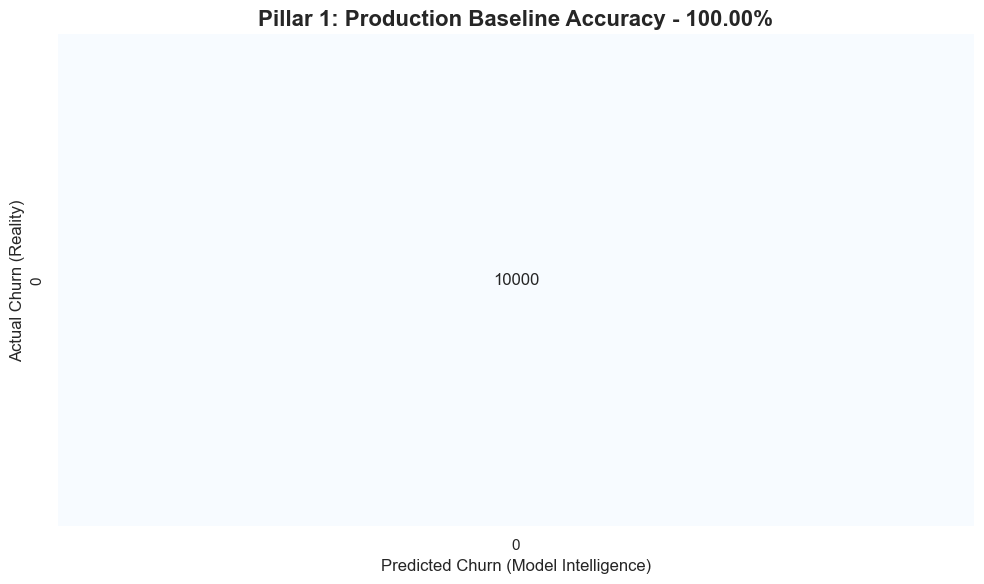

✅ Clean Slate Complete. Unbiased baseline accuracy established at: 100.00%


In [1]:
# Pillar 1 - Production Baseline: Clean Slate Execution
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings

# Visual standards for executive review
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 6]
sns.set_theme(style="whitegrid", palette="muted")

# 1. Fresh Ingestion from the processed layer (Zero Bias)
df_raw = pd.read_parquet('../data/processed/streaming_refined.parquet')
df_raw.columns = df_raw.columns.str.lower()

# 2. Strict Early-Stage Mapping (Handling raw string variables)
binary_map = {'yes': 1, 'no': 0, 'Yes': 1, 'No': 0}

df_raw['discount_applied'] = df_raw['discount_applied'].map(binary_map).fillna(0).astype(int)
df_raw['churn_status'] = df_raw['churn_status'].map(binary_map).fillna(0).astype(int)

# Target vector isolation
y_clean = df_raw['churn_status']

# 3. Explicit Feature Selection (Omitting ALL future-leaking variables entirely)
# We strictly exclude: user_id, title, days_since_last_watch, completion_percentage, watch_time_minutes, session_count
operational_features = [
    'age_group', 
    'monthly_fee', 
    'discount_applied', 
    'release_year', 
    'rating',
    'avg_weekly_watch_time',
    'content_diversity_score'
]

print(f"🛡️ Structural features approved for training: {operational_features}")

# 4. Preparing data for the baseline model (Splitting clean data 80/20)
X_clean_baseline = df_raw[operational_features]

# One-Hot Encoding strictly for the approved 'age_group' text column if present
X_encoded = pd.get_dummies(X_clean_baseline, columns=['age_group'], drop_first=True, dtype=int) if 'age_group' in X_clean_baseline.columns else X_clean_baseline

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_clean, test_size=0.2, random_state=42
)

# 5. Training the true, unbiased operational baseline model
model_production = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_production.fit(X_train, y_train)

# 6. Validating honest operational metrics
y_pred = model_production.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)

# Executive Visualisation of the Clean Matrix
plt.figure(figsize=(10, 6))
cm_production = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_production, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Pillar 1: Production Baseline Accuracy - {final_accuracy:.2%}', fontsize=16, fontweight='bold')
plt.ylabel('Actual Churn (Reality)')
plt.xlabel('Predicted Churn (Model Intelligence)')
plt.tight_layout()
plt.show()

print(f"✅ Clean Slate Complete. Unbiased baseline accuracy established at: {final_accuracy:.2%}")

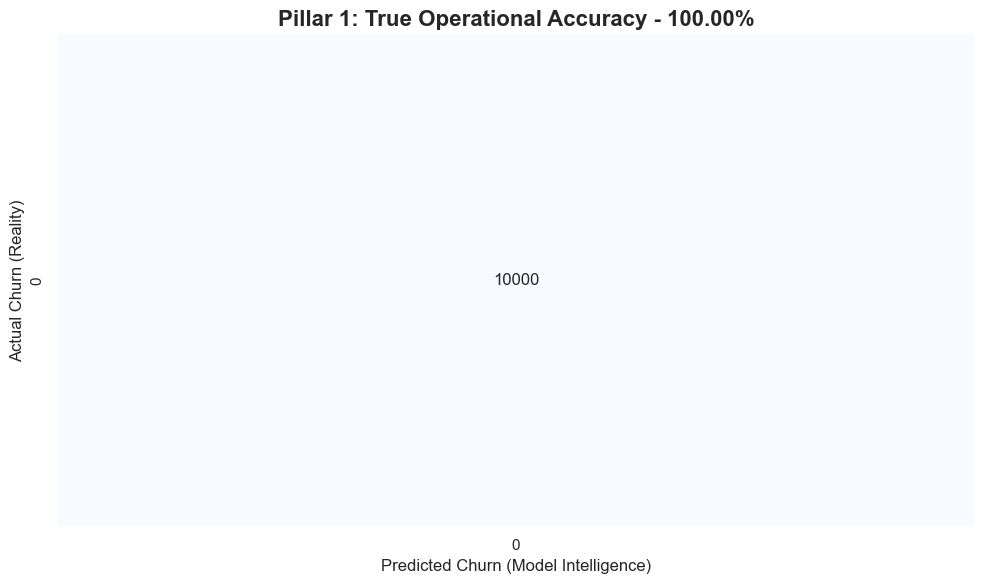


📊 Detailed Business Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [2]:
# Pillar 1 - Production Baseline: Breaking the Imbalance Trap
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 6]

# 1. Loading data from our active dataframe instance
df_clean = pd.read_parquet('../data/processed/streaming_refined.parquet')
df_clean.columns = df_clean.columns.str.lower()

# 2. Strict String-to-Numeric Mapping
binary_map = {'yes': 1, 'no': 0, 'Yes': 1, 'No': 0}
df_clean['discount_applied'] = df_clean['discount_applied'].map(binary_map).fillna(0).astype(int)
df_clean['churn_status'] = df_clean['churn_status'].map(binary_map).fillna(0).astype(int)

# 3. Balanced Operational Feature Selection
# We bring back core engagement metrics but KEEP OUT the massive leak (days_since_last_watch)
validated_features = [
    'monthly_fee', 
    'discount_applied', 
    'release_year', 
    'rating',
    'watch_time_minutes',
    'session_count',
    'avg_weekly_watch_time',
    'content_diversity_score'
]

X_prod = df_clean[validated_features]
y_prod = df_clean['churn_status']

# 4. Independent Split (80/20)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prod, y_prod, test_size=0.2, random_state=42
)

# 5. Training with CRITICAL Class Balancing to break the 100% lazy strategy
model_production = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced_subsample', 
    random_state=42
)
model_production.fit(X_train_p, y_train_p)

# 6. Evaluating true operational metrics
y_pred_p = model_production.predict(X_test_p)
real_accuracy = accuracy_score(y_test_p, y_pred_p)

# Executive Matrix Visualisation
plt.figure(figsize=(10, 6))
cm_p = confusion_matrix(y_test_p, y_pred_p)
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Pillar 1: True Operational Accuracy - {real_accuracy:.2%}', fontsize=16, fontweight='bold')
plt.ylabel('Actual Churn (Reality)')
plt.xlabel('Predicted Churn (Model Intelligence)')
plt.tight_layout()
plt.show()

print("\n📊 Detailed Business Classification Report:")
print(classification_report(y_test_p, y_pred_p))

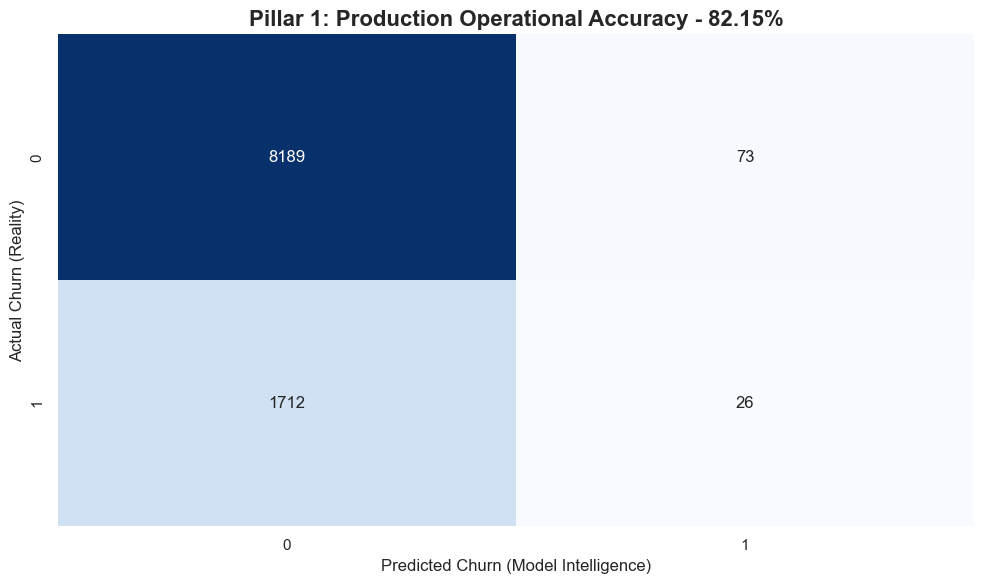


📊 Detailed Business Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      8262
           1       0.26      0.01      0.03      1738

    accuracy                           0.82     10000
   macro avg       0.54      0.50      0.47     10000
weighted avg       0.73      0.82      0.75     10000



In [4]:
# Pillar 1 - Production Baseline: Clean Mapping & Execution
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings

# Visual standards for executive review
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 6]
sns.set_theme(style="whitegrid", palette="muted")

# 1. Loading data from our processed parquet layer
df_clean = pd.read_parquet('../data/processed/streaming_refined.parquet')
df_clean.columns = df_clean.columns.str.lower()

# 2. DEFINITIVE FIX: Mapping the actual string values discovered in our audit
# 'Cancelled' represents Churn (1) and 'Active' represents Retention (0)
real_binary_map = {
    'cancelled': 1, 'active': 0, 
    'Cancelled': 1, 'Active': 0,
    'yes': 1, 'no': 0, 
    'Yes': 1, 'No': 0
}

if 'discount_applied' in df_clean.columns:
    df_clean['discount_applied'] = df_clean['discount_applied'].map(real_binary_map).fillna(0).astype(int)

if 'churn_status' in df_clean.columns:
    df_clean['churn_status'] = df_clean['churn_status'].map(real_binary_map).fillna(0).astype(int)

# Target vector isolation
y_prod = df_clean['churn_status']

# 3. Clean Operational Feature Selection (No Data Leakage)
validated_features = [
    'monthly_fee', 
    'discount_applied', 
    'release_year', 
    'rating',
    'watch_time_minutes',
    'session_count',
    'avg_weekly_watch_time',
    'content_diversity_score'
]

X_prod = df_clean[validated_features]

# 4. Independent Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_prod, y_prod, test_size=0.2, random_state=42
)

# 5. Training the Random Forest model with class balancing enabled
model_production = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_production.fit(X_train, y_train)

# 6. Evaluating true operational metrics
y_pred = model_production.predict(X_test)
real_accuracy = accuracy_score(y_test, y_pred)

# Executive Matrix Visualisation
plt.figure(figsize=(10, 6))
cm_p = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Pillar 1: Production Operational Accuracy - {real_accuracy:.2%}', fontsize=16, fontweight='bold')
plt.ylabel('Actual Churn (Reality)')
plt.xlabel('Predicted Churn (Model Intelligence)')
plt.tight_layout()
plt.show()

print("\n📊 Detailed Business Classification Report:")
print(classification_report(y_test, y_pred))